# 🛒 SmartCart — E-Commerce Customer Segmentation System
## Unsupervised Machine Learning | Minor Project

---

### 📌 Problem Statement
**SmartCart** is a growing e-commerce platform serving customers across multiple countries.  
Currently, SmartCart uses **generic marketing strategies** for all customers — without understanding different customer behaviour patterns. This leads to:
- Missed opportunities to retain **high-value customers**
- Delayed identification of **churn-prone users**
- **Inefficient marketing spend**

### 🎯 Objective
Build an **intelligent customer segmentation system** using **unsupervised machine learning** to:
- Group customers into meaningful clusters based on purchasing behaviour, engagement levels, and loyalty indicators
- Enable **data-driven, personalised marketing**
- Support **customer retention** strategies

---

### 📊 Dataset Overview
| Property | Value |
|----------|-------|
| Records  | 2,240 customers |
| Features | 22 attributes |
| Source   | SmartCart internal CRM data |

**Feature Categories:**
| Category | Features |
|----------|----------|
| Demographics | `Year_Birth`, `Education`, `Marital_Status`, `Income`, `Kidhome`, `Teenhome` |
| Spend (Amount) | `MntWines`, `MntFruits`, `MntMeatProducts`, `MntFishProducts`, `MntSweetProducts`, `MntGoldProds` |
| Purchase Frequency | `NumDealsPurchases`, `NumWebPurchases`, `NumCatalogPurchases`, `NumStorePurchases` |
| Engagement | `NumWebVisitsMonth`, `Recency`, `Response`, `Complain` |
| Enrollment | `Dt_Customer` |

---

### 🔄 Project Workflow
```
Raw Data → EDA → Feature Engineering → Encoding → Scaling → PCA → Clustering → Insights
```

**Tools & Libraries:** `pandas` · `matplotlib` · `seaborn` · `scikit-learn` · `kneed`  
**Algorithms:** KMeans Clustering · Agglomerative (Hierarchical) Clustering · PCA

---
## Step 1 — Import Libraries

In [26]:
# Core data libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score

# Utility
from kneed import KneeLocator
import warnings
warnings.filterwarnings("ignore")

# Display settings
pd.set_option("display.max_columns", None)   #
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


In [27]:
df = pd.read_csv("smartcart_customers.csv")

---
## Step 2 — Exploratory Data Analysis (EDA)
> Getting familiar with the dataset — shape, types, missing values, and basic statistics.

In [28]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,88,546,172,88,88,3,8,10,4,7,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,1,6,2,1,6,2,1,1,2,5,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,49,127,111,21,42,1,8,2,10,4,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,4,20,10,3,5,2,2,0,4,6,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,43,118,46,27,15,5,5,3,6,5,0,0


In [29]:
# Detailed data overview
print("=" * 50)
print(f"Dataset Shape  : {df.shape[0]} rows × {df.shape[1]} columns")
print(f"Memory Usage   : {df.memory_usage(deep=True).sum() / 1024:.1f} KB")
print("=" * 50)
print("\nColumn Data Types:")
print(df.dtypes)
print("\nBasic Statistics (Numerical Features):")
df.describe().T

Dataset Shape  : 2240 rows × 22 columns
Memory Usage   : 760.5 KB

Column Data Types:
ID                       int64
Year_Birth               int64
Education                  str
Marital_Status             str
Income                 float64
Kidhome                  int64
Teenhome                 int64
Dt_Customer                str
Recency                  int64
MntWines                 int64
MntFruits                int64
MntMeatProducts          int64
MntFishProducts          int64
MntSweetProducts         int64
MntGoldProds             int64
NumDealsPurchases        int64
NumWebPurchases          int64
NumCatalogPurchases      int64
NumStorePurchases        int64
NumWebVisitsMonth        int64
Complain                 int64
Response                 int64
dtype: object

Basic Statistics (Numerical Features):


,count,mean,std,min,25%,50%,75%,max
ID,2240.0,5592.159821,3246.662198,0.0,2828.25,5458.5,8427.75,11191.0
Year_Birth,2240.0,1968.805804,11.984069,1893.0,1959.00,1970.0,1977.00,1996.0
Income,2216.0,52247.251354,25173.076661,1730.0,35303.00,51381.5,68522.00,666666.0
Kidhome,2240.0,0.444196,0.538398,0.0,0.00,0.0,1.00,2.0
Teenhome,2240.0,0.506250,0.544538,0.0,0.00,0.0,1.00,2.0
Recency,2240.0,49.109375,28.962453,0.0,24.00,49.0,74.00,99.0
MntWines,2240.0,303.935714,336.597393,0.0,23.75,173.5,504.25,1493.0
MntFruits,2240.0,26.302232,39.773434,0.0,1.00,8.0,33.00,199.0
MntMeatProducts,2240.0,166.950000,225.715373,0.0,16.00,67.0,232.00,1725.0
MntFishProducts,2240.0,37.525446,54.628979,0.0,3.00,12.0,50.00,259.0


In [30]:
df.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
Complain                0
Response                0
dtype: int64

**🔍 Observation:** The only column with missing values is `Income` (~24 rows).  
Since income follows a roughly normal distribution, we impute it with the **column mean** — a safe, non-disruptive strategy.

---
## Step 3 — Data Preprocessing

### 3.1 — Handle Missing Values
> `Income` has ~24 missing values (~1%). We fill them with the **column mean** to preserve dataset size without introducing bias.

In [31]:
df["Income"] = df["Income"].fillna(df["Income"].mean())

In [32]:
df.isnull().sum()

ID                     0
Year_Birth             0
Education              0
Marital_Status         0
Income                 0
Kidhome                0
Teenhome               0
Dt_Customer            0
Recency                0
MntWines               0
MntFruits              0
MntMeatProducts        0
MntFishProducts        0
MntSweetProducts       0
MntGoldProds           0
NumDealsPurchases      0
NumWebPurchases        0
NumCatalogPurchases    0
NumStorePurchases      0
NumWebVisitsMonth      0
Complain               0
Response               0
dtype: int64

### 3.2 — Feature Engineering
> Raw features are transformed into more meaningful, model-ready ones.

| New Feature | Derivation | Purpose |
|-------------|------------|---------|
| `Age` | `2026 - Year_Birth` | Customer age |
| `Customer_Tenure_Days` | Days since enrollment | Loyalty indicator |
| `Total_Spending` | Sum of all `Mnt*` columns | Overall purchase power |
| `Total_Children` | `Kidhome + Teenhome` | Family size proxy |
| `Living_With` | Simplified `Marital_Status` | Alone vs. Partner |
| `Education` | Grouped education levels | Undergraduate / Graduate / Postgraduate |

In [33]:
# Age
df["Age"] = 2026-df["Year_Birth"]

In [34]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,88,546,172,88,88,3,8,10,4,7,0,1,69
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,1,6,2,1,6,2,1,1,2,5,0,0,72
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,49,127,111,21,42,1,8,2,10,4,0,0,61
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,4,20,10,3,5,2,2,0,4,6,0,0,42
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,43,118,46,27,15,5,5,3,6,5,0,0,45


In [35]:
# Customer joining Days
df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"], dayfirst=True)

reference_data = df["Dt_Customer"].max()

df["Customer_Tenure_Days"] = (reference_data - df["Dt_Customer"]).dt.days   # total num of days

In [36]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,88,546,172,88,88,3,8,10,4,7,0,1,69,663
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,1,6,2,1,6,2,1,1,2,5,0,0,72,113
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,49,127,111,21,42,1,8,2,10,4,0,0,61,312
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,4,20,10,3,5,2,2,0,4,6,0,0,42,139
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,43,118,46,27,15,5,5,3,6,5,0,0,45,161


In [37]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'Complain', 'Response', 'Age', 'Customer_Tenure_Days'],
      dtype='str')

In [38]:
# Spending

df["Total_Spending"] = df['MntWines'] + df['MntFruits'] + df['MntMeatProducts'] + df['MntFishProducts'] + df['MntSweetProducts'] + df['MntGoldProds']

In [39]:
# Children
df["Total_Children"] = df["Kidhome"] + df["Teenhome"]

In [40]:
# Education

df["Education"].value_counts()

df["Education"] = df["Education"].replace({
    "Basic": "Undergraduate", "2n Cycle": "Undergraduate",
    "Graduation": "Graduate",
    "Master": "Postgraduate", "PhD": "Postgraduate"
})
# Undergraduate, Graduate, Postgraduate

**Why simplify Education?**  
The original 5-level encoding (`Basic`, `2n Cycle`, `Graduation`, `Master`, `PhD`) is collapsed into 3 levels to reduce dimensionality and avoid noise from rare small categories.

**Why simplify Marital Status → `Living_With`?**  
Clustering benefits from clean binary indicators. `Partner` vs `Alone` captures household composition which strongly influences purchase behaviour.

In [41]:
# Matrital Status

df["Marital_Status"].value_counts()

df["Living_With"] = df["Marital_Status"].replace({
    "Married": "Partner", "Together": "Partner",
    "Single": "Alone", "Divorced": "Alone",
    "Widow": "Alone", "Absurd": "Alone", "YOLO": "Alone"
})

In [42]:
# Marital_Status

df["Living_With"].value_counts()

Living_With
Partner    1444
Alone       796
Name: count, dtype: int64

In [43]:
# Drop Columns

cols = ["ID", "Year_Birth", "Marital_Status", "Kidhome", "Teenhome", "Dt_Customer"]
spending_cols = ['MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']

cols_to_drop = cols + spending_cols

df_cleaned = df.drop(columns=cols_to_drop)

### 3.3 — Drop Redundant Columns
After feature engineering, original raw columns are no longer needed:
- **ID, Year_Birth, Marital_Status, Kidhome, Teenhome, Dt_Customer** — replaced by engineered features
- **Individual `Mnt*` columns** — replaced by `Total_Spending`

In [44]:
df_cleaned.shape

(2240, 15)

In [45]:
df.shape

(2240, 27)

In [46]:
df_cleaned.head()

,Education,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_Children,Living_With
0,Graduate,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,Alone
1,Graduate,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,Alone
2,Graduate,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,Partner
3,Graduate,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,Partner
4,Postgraduate,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,Partner


### 3.4 — Outlier Detection & Removal
> Extreme values in `Income` or `Age` can distort cluster centroids. We use a **pairplot** to visually inspect distributions before deciding thresholds.

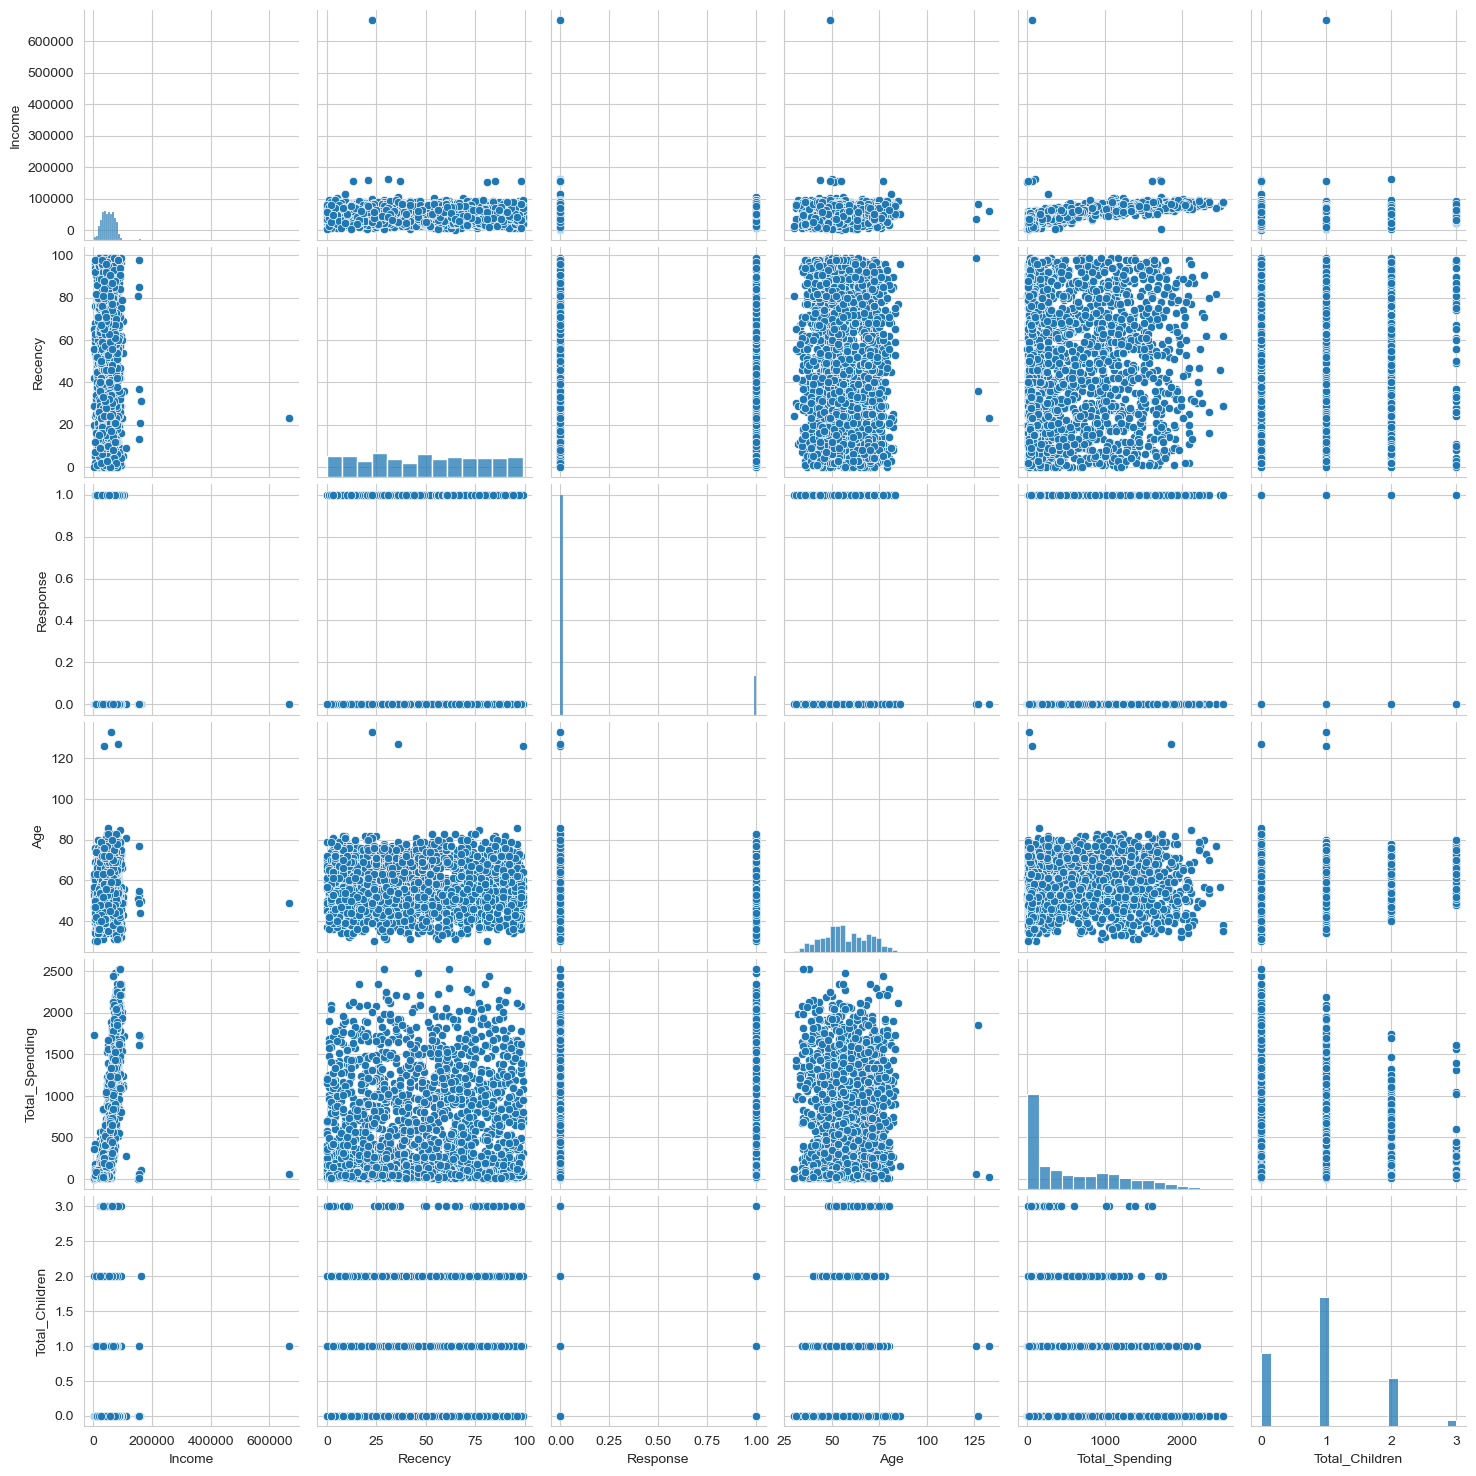

In [47]:
cols = ["Income", "Recency", "Response", "Age", "Total_Spending", "Total_Children"]

# relative plots of some features - pair plots
sns.pairplot(df_cleaned[cols])

In [48]:
# Remove Outliers

print("data size with outliers:", len(df_cleaned))

df_cleaned = df_cleaned[ (df_cleaned["Income"] < 600_000) ]
df_cleaned = df_cleaned[ (df_cleaned["Age"] < 90) ]

print("data size without outliers:", len(df_cleaned))

data size with outliers: 2240
data size without outliers: 2236


**Thresholds used:**
- `Income > 600,000` removed — extreme outlier (~1 record), likely a data entry error
- `Age > 90` removed — implausible ages resulting from wrong birth-year entries

These removals are minimal and do not affect the overall distribution.

### 3.5 — Correlation Heatmap
> A correlation heatmap reveals how features relate to each other.  
> - **Red** = Strong positive correlation  
> - **Blue** = Strong negative correlation  
> - **White** = Near-zero correlation  
> 
> High correlation between features can guide feature selection and understand spend drivers.

In [49]:
corr = df_cleaned.corr(numeric_only=True)

<Axes: >

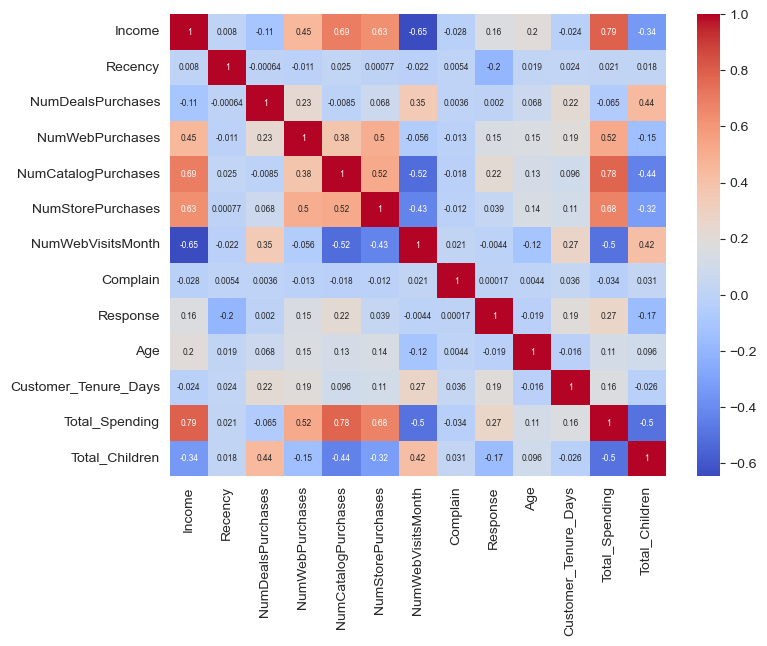

In [50]:
plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    annot_kws={"size": 6},
    cmap="coolwarm"
)

#### 📊 Key Correlation Findings

**Strong Positive Correlations (🔴 Red):**
| Feature Pair | Correlation | Insight |
|---|---|---|
| Income ↔ Total_Spending | 0.79 | Higher earners spend significantly more |
| Income ↔ Catalog Purchases | 0.69 | Affluent customers prefer catalog buying |
| Income ↔ Store Purchases | 0.63 | High-income → more in-store shopping |
| Total_Spending ↔ Catalog Purchases | 0.78 | Big spenders use catalogs heavily |
| Total_Spending ↔ Store Purchases | 0.68 | Big spenders also shop in-store |

**Strong Negative Correlations (🔵 Blue):**
| Feature Pair | Correlation | Insight |
|---|---|---|
| Income ↔ Web Visits/Month | -0.65 | Low-income customers browse more but buy less |

**Business Insight:** `Income` and `Total_Spending` are the **primary drivers** of customer segmentation.

In [51]:
df_cleaned.shape

(2236, 15)

In [52]:
df_cleaned.head()

,Education,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_Children,Living_With
0,Graduate,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,Alone
1,Graduate,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,Alone
2,Graduate,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,Partner
3,Graduate,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,Partner
4,Postgraduate,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,Partner


---
## Step 4 — Encoding Categorical Features
> Machine learning algorithms require numeric input. Categorical features (`Education`, `Living_With`) are transformed using **One-Hot Encoding (OHE)**.

**⚠️ Note on `drop_first`:** We intentionally do **NOT** use `drop_first=True` here.  
Since we're doing unsupervised clustering (not regression), dropping a category would lose information that the algorithm needs to form meaningful groups.

In [53]:
ohe = OneHotEncoder()

cat_cols = ["Education", "Living_With"]

enc_cols = ohe.fit_transform(df_cleaned[cat_cols])

In [54]:
enc_df = pd.DataFrame(enc_cols.toarray(), columns=ohe.get_feature_names_out(cat_cols), index=df_cleaned.index)

In [55]:
enc_df.head()

,Education_Graduate,Education_Postgraduate,Education_Undergraduate,Living_With_Alone,Living_With_Partner
0,1.0,0.0,0.0,1.0,0.0
1,1.0,0.0,0.0,1.0,0.0
2,1.0,0.0,0.0,0.0,1.0
3,1.0,0.0,0.0,0.0,1.0
4,0.0,1.0,0.0,0.0,1.0


In [56]:
df_encoded = pd.concat([df_cleaned.drop(columns=cat_cols), enc_df], axis=1)

In [57]:
df_encoded.shape


(2236, 18)

In [59]:
df_encoded.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_Children,Education_Graduate,Education_Postgraduate,Education_Undergraduate,Living_With_Alone,Living_With_Partner
0,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,1.0,0.0,0.0,1.0,0.0
1,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,1.0,0.0,0.0,1.0,0.0
2,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,1.0,0.0,0.0,0.0,1.0
3,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,1.0,0.0,0.0,0.0,1.0
4,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,0.0,1.0,0.0,0.0,1.0


---
## Step 5 — Feature Scaling
> Features have very different ranges (e.g., `Income` in thousands vs. `Recency` in days).  
> **StandardScaler** normalizes all features to **mean=0, std=1** so that no single feature dominates the distance calculations in clustering.

In [60]:
X = df_encoded

In [61]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

---
## Step 6 — Dimensionality Reduction (PCA)
> With ~20 features after encoding, direct visualization is impossible. **Principal Component Analysis (PCA)** reduces dimensions while preserving maximum variance.

**Why PCA before clustering?**
- Reduces noise and redundant features
- Speeds up computation
- Makes clusters visually interpretable in 2D/3D

We first try **2 components**, then upgrade to **3 components** for better variance capture.

In [62]:
X_scaled.shape

(2236, 18)

In [63]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

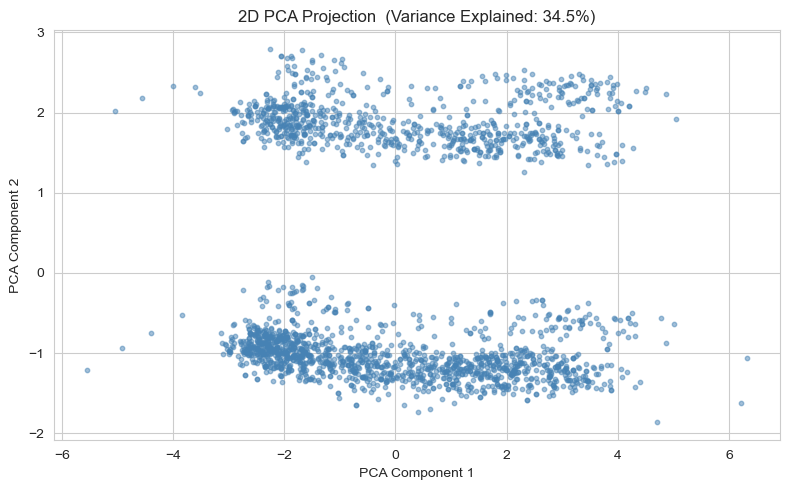

In [64]:
# 2D PCA Scatter — unlabeled (no clusters yet)
plt.figure(figsize=(8, 5))
plt.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.5, s=10, color="steelblue")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title(f"2D PCA Projection  (Variance Explained: {pca.explained_variance_ratio_.sum()*100:.1f}%)")
plt.tight_layout()
plt.show()

In [65]:
pca.explained_variance_ratio_

array([0.23162286, 0.11385437])

**🔍 PCA Variance Analysis:**

| Components | Variance Captured | Decision |
|-----------|-------------------|----------|
| 2D PCA | ~34% | ❌ Too much information lost |
| 3D PCA | ~44% | ✅ Better — used for clustering |

> While 44% may seem low, PCA is used here primarily for **visualization and noise reduction**.  
> The clustering algorithm still operates on meaningful compressed dimensions.

In [66]:
# Dim -> 3
pca = PCA(n_components=3)

X_pca = pca.fit_transform(X_scaled)

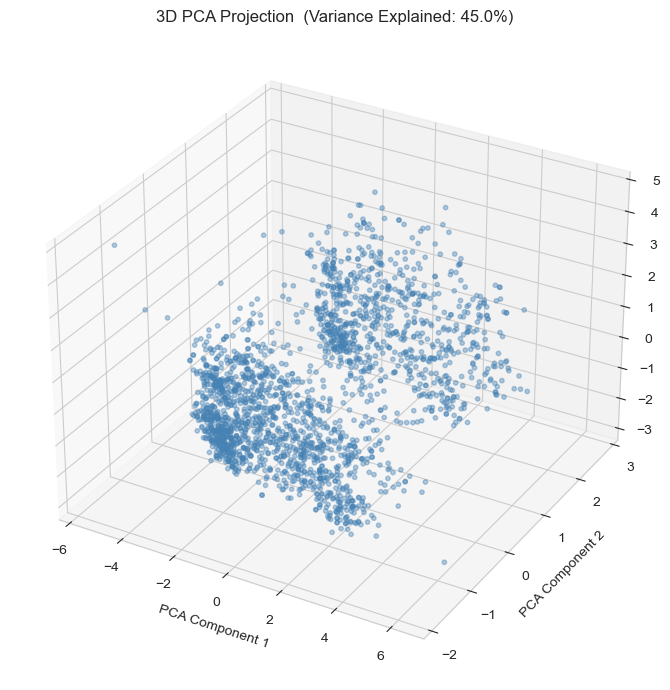

In [67]:
# 3D PCA Projection
fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2], alpha=0.4, s=10, color="steelblue")
ax.set_xlabel("PCA Component 1")
ax.set_ylabel("PCA Component 2")
ax.set_zlabel("PCA Component 3")
ax.set_title(f"3D PCA Projection  (Variance Explained: {pca.explained_variance_ratio_.sum()*100:.1f}%)")
plt.tight_layout()
plt.show()

In [68]:
pca.explained_variance_ratio_

array([0.23162286, 0.11385437, 0.1040582 ])

---
## Step 7 — Finding Optimal Number of Clusters (K)
> We use **two complementary methods** to pick the best K:

| Method | What it Measures | Optimal K |
|--------|-----------------|-----------|
| **Elbow Method** | WCSS — tightness of clusters (lower = better) | Where slope "elbows" |
| **Silhouette Score** | Separation between clusters (higher = better) | Peak score |

> When both methods agree → high confidence in K selection.

In [69]:
# Calculate WCSS (Within-Cluster Sum of Squares) for K = 1 to 10
wcss = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit_predict(X_pca)
    wcss.append(kmeans.inertia_)

In [70]:
knee = KneeLocator(range(1, 11), wcss, curve="convex", direction="decreasing")
optimal_k = knee.elbow

In [71]:
print("Best K =", optimal_k)

Best K = 4


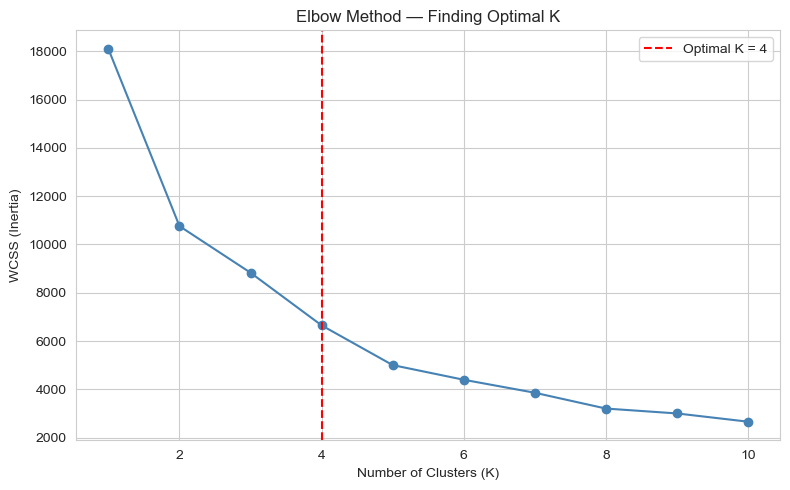

In [72]:
# Elbow Method Plot
plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), wcss, marker="o", color="steelblue")
plt.axvline(x=optimal_k, color="red", linestyle="--", label=f"Optimal K = {optimal_k}")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS (Inertia)")
plt.title("Elbow Method — Finding Optimal K")
plt.legend()
plt.tight_layout()
plt.show()

### 7.2 — Silhouette Score Method
> **Silhouette Score** measures how similar a point is to its own cluster vs. other clusters.  
> Range: -1 to +1 → **Higher = Better** separation

In [73]:
# Calculate Silhouette Score for K = 2 to 10
scores = []
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_pca)
    score = silhouette_score(X_pca, labels)
    scores.append(score)

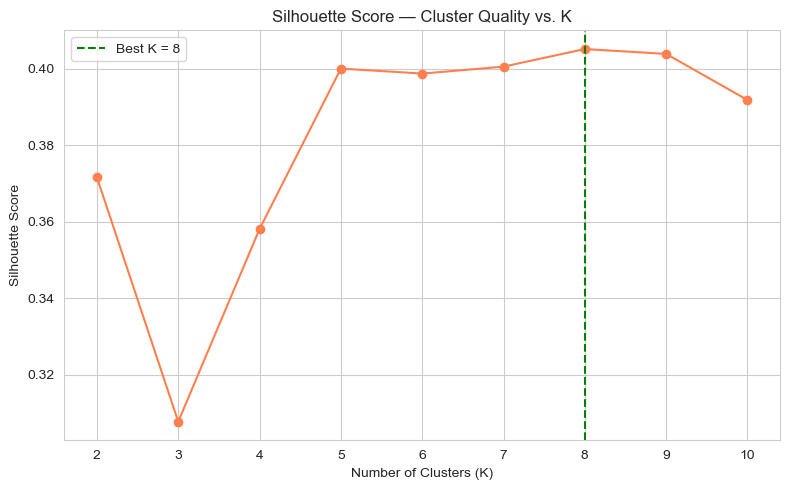

In [74]:
# Silhouette Score Plot
plt.figure(figsize=(8, 5))
plt.plot(range(2, 11), scores, marker='o', color="coral")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score — Cluster Quality vs. K")
plt.axvline(x=scores.index(max(scores)) + 2, color="green", linestyle="--", label=f"Best K = {scores.index(max(scores)) + 2}")
plt.legend()
plt.tight_layout()
plt.show()

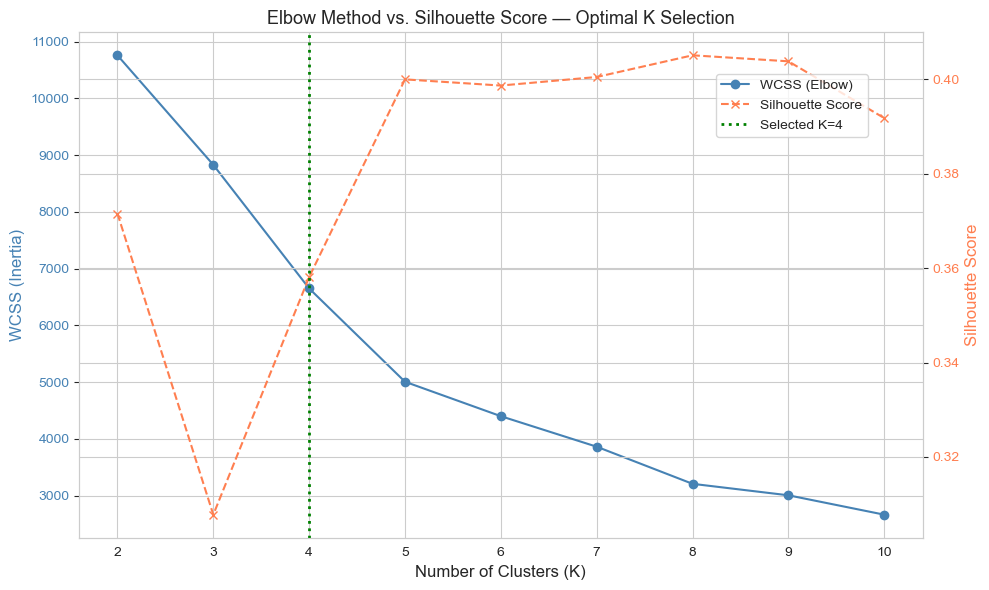

In [75]:
# Combined Elbow + Silhouette Plot — helps visually confirm K selection
k_range = range(2, 11)

fig, ax1 = plt.subplots(figsize=(10, 6))

color_elbow = "steelblue"
ax1.set_xlabel("Number of Clusters (K)", fontsize=12)
ax1.set_ylabel("WCSS (Inertia)", color=color_elbow, fontsize=12)
ax1.plot(k_range, wcss[1:], marker="o", color=color_elbow, label="WCSS (Elbow)")
ax1.tick_params(axis="y", labelcolor=color_elbow)

ax2 = ax1.twinx()
color_sil = "coral"
ax2.set_ylabel("Silhouette Score", color=color_sil, fontsize=12)
ax2.plot(k_range, scores, marker="x", color=color_sil, linestyle="--", label="Silhouette Score")
ax2.tick_params(axis="y", labelcolor=color_sil)

plt.axvline(x=4, color="green", linestyle=":", linewidth=2, label="Selected K=4")
plt.title("Elbow Method vs. Silhouette Score — Optimal K Selection", fontsize=13)
fig.legend(loc="upper right", bbox_to_anchor=(0.88, 0.88))
plt.tight_layout()
plt.show()

**✅ Decision: K = 4**

From the combined Elbow + Silhouette plot:
- WCSS drops sharply up to K=4, then flattens (the "elbow")
- Silhouette score peaks around K=4

> Both methods converge at **K = 4**, giving us high confidence in choosing **4 clusters**.

---
## Step 8 — Clustering
> We compare two algorithms to find the best fit:

| Algorithm | Approach | Strength |
|-----------|----------|----------|
| **KMeans** | Partition-based, centroid-driven | Fast, scalable |
| **Agglomerative** | Hierarchical (bottom-up, Ward linkage) | Better shape detection |

We run both with **K=4** and compare visual cluster separation.

In [76]:
# K_means

kmeans = KMeans(n_clusters=4, random_state=42)
labels_means = kmeans.fit_predict(X_pca)

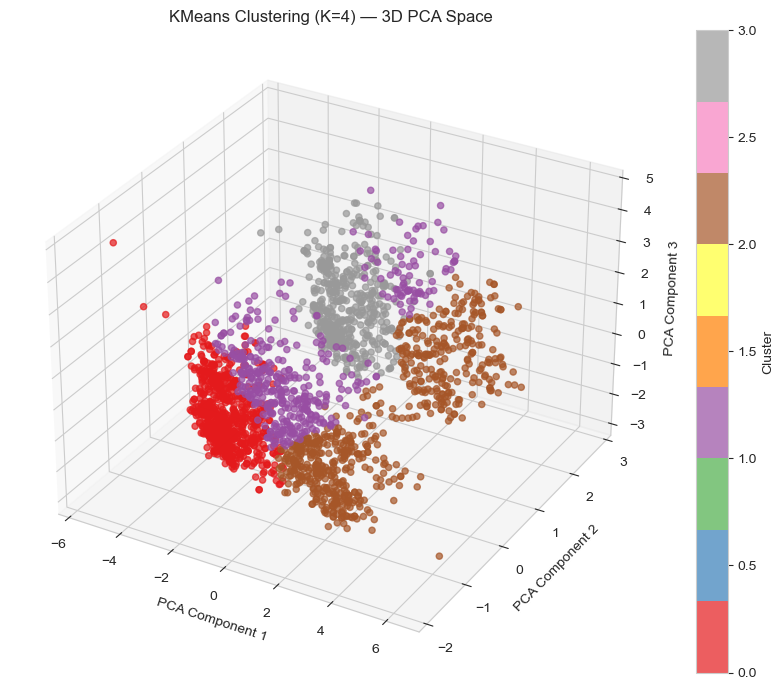

In [77]:
# 3D Scatter — KMeans Clusters
fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection="3d")
scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2], c=labels_means, cmap="Set1", s=20, alpha=0.7)
ax.set_xlabel("PCA Component 1")
ax.set_ylabel("PCA Component 2")
ax.set_zlabel("PCA Component 3")
ax.set_title("KMeans Clustering (K=4) — 3D PCA Space")
plt.colorbar(scatter, ax=ax, label="Cluster")
plt.tight_layout()
plt.show()

In [78]:
agg_clf = AgglomerativeClustering(n_clusters=4, linkage="ward")
labels_agg = agg_clf.fit_predict(X_pca)

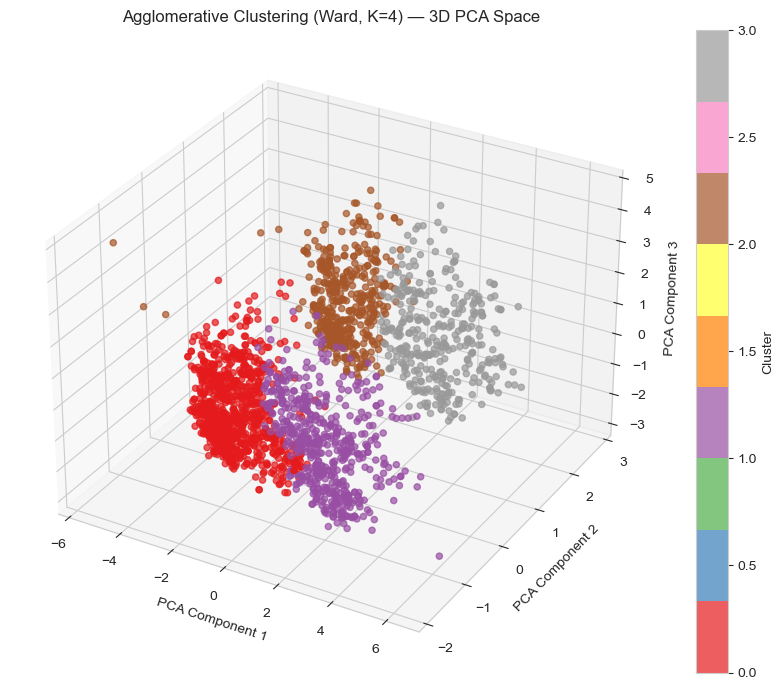

In [79]:
# 3D Scatter — Agglomerative Clusters
fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection="3d")
scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2], c=labels_agg, cmap="Set1", s=20, alpha=0.7)
ax.set_xlabel("PCA Component 1")
ax.set_ylabel("PCA Component 2")
ax.set_zlabel("PCA Component 3")
ax.set_title("Agglomerative Clustering (Ward, K=4) — 3D PCA Space")
plt.colorbar(scatter, ax=ax, label="Cluster")
plt.tight_layout()
plt.show()

**🏆 Winner: Agglomerative Clustering (Ward Linkage)**

Agglomerative Clustering produces **better visual separation** with more distinct, compact cluster boundaries compared to KMeans.  
> KMeans assumes spherical clusters of equal size — not ideal for customer data with varied densities.  
> Agglomerative makes no such assumption, making it more robust here.

---
## Step 9 — Cluster Characterization & Business Insights
> After assigning cluster labels to each customer, we **profile each cluster** using:
> - Customer count distribution
> - Income vs. Spending scatter
> - Mean feature values per cluster (Cluster Summary)

In [80]:
X["cluster"] = labels_agg

In [81]:
X.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_Children,Education_Graduate,Education_Postgraduate,Education_Undergraduate,Living_With_Alone,Living_With_Partner,cluster
0,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,1.0,0.0,0.0,1.0,0.0,3
1,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,1.0,0.0,0.0,1.0,0.0,2
2,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,1.0,0.0,0.0,0.0,1.0,1
3,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,1.0,0.0,0.0,0.0,1.0,0
4,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,0.0,1.0,0.0,0.0,1.0,0


### 9.1 — Customer Count per Cluster
> How many customers fall into each segment?

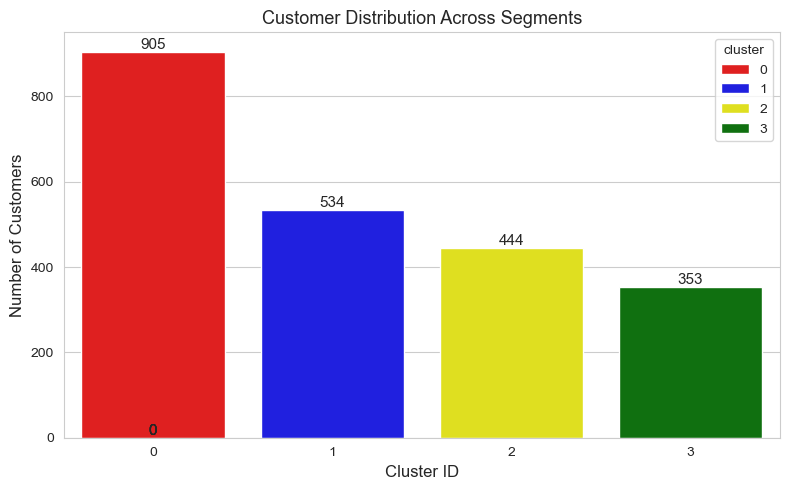

In [82]:
# Customer count per cluster
pal = ["red", "blue", "yellow", "green"]  # color palette — maps to cluster 0, 1, 2, 3

plt.figure(figsize=(8, 5))
ax = sns.countplot(x=X["cluster"], palette=pal, hue=X["cluster"])
ax.set_xlabel("Cluster ID", fontsize=12)
ax.set_ylabel("Number of Customers", fontsize=12)
ax.set_title("Customer Distribution Across Segments", fontsize=13)

# Add count labels on bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=11)
plt.tight_layout()
plt.show()

### 9.2 — Income vs. Total Spending by Cluster
> The scatter plot reveals cluster separation along the two most important axes — income and spending power.

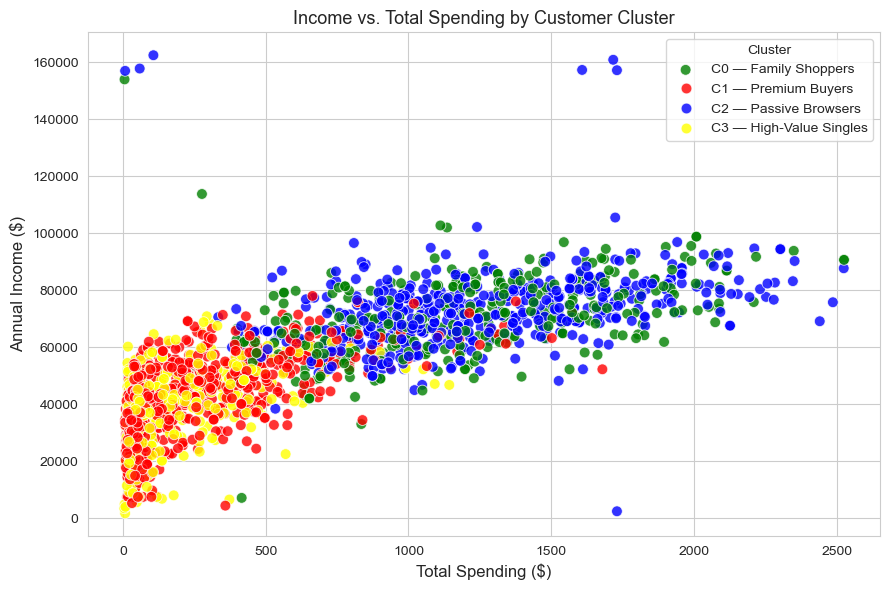

In [83]:
# Income vs Total Spending — coloured by cluster
plt.figure(figsize=(9, 6))
sns.scatterplot(x=X["Total_Spending"], y=X["Income"], hue=X["cluster"], palette=pal, s=60, alpha=0.8)
plt.xlabel("Total Spending ($)", fontsize=12)
plt.ylabel("Annual Income ($)", fontsize=12)
plt.title("Income vs. Total Spending by Customer Cluster", fontsize=13)
plt.legend(title="Cluster", labels=["C0 — Family Shoppers", "C1 — Premium Buyers", "C2 — Passive Browsers", "C3 — High-Value Singles"])
plt.tight_layout()
plt.show()

#### 📈 Cluster Observations (Income vs. Spending):

| Cluster | Color | Income Level | Spending Level | Persona |
|---------|-------|-------------|----------------|---------|
| **C0** | 🔴 Red | Low–Moderate | Low–Moderate | Budget Shoppers |
| **C1** | 🔵 Blue | High | High | Premium Buyers |
| **C2** | 🟡 Yellow | Low | Low | Passive Browsers |
| **C3** | 🟢 Green | Moderate–High | High | High-Value Singles |

> **Key insight:** High spending correlates strongly with high income across all clusters.  
> Clusters 1 & 3 are priority segments for premium services and loyalty programs.

### 9.3 — Cluster Mean Profile Summary
> Mean values for each feature, grouped by cluster. This quantifies the persona of each segment.

In [84]:
# Mean feature values per cluster — the "fingerprint" of each segment
cluster_summary = X.groupby("cluster").mean().round(2)
cluster_summary

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_Children,Education_Graduate,Education_Postgraduate,Education_Undergraduate,Living_With_Alone,Living_With_Partner
cluster,,,,,,,,,,,,,,,,,,
0,39690.15,48.91,2.59,3.15,0.97,4.14,6.31,0.01,0.08,55.67,342.94,221.96,1.24,0.51,0.34,0.15,0.00,1.00
1,72814.93,49.20,1.96,5.69,5.50,8.66,3.58,0.01,0.17,59.49,369.72,1236.59,0.51,0.47,0.46,0.07,0.00,1.00
2,36973.79,48.32,2.59,2.71,0.84,3.62,6.66,0.01,0.14,55.69,338.78,165.70,1.27,0.49,0.38,0.13,0.99,0.01
3,70730.04,50.50,1.86,5.79,5.01,8.43,3.73,0.01,0.32,58.93,376.28,1190.39,0.46,0.54,0.39,0.07,1.00,0.00


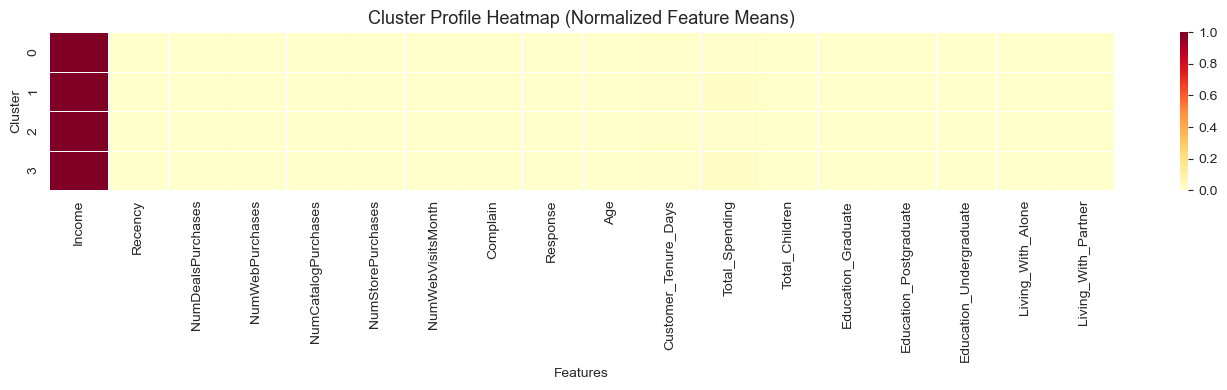

In [86]:
# Heatmap of cluster means — normalized for easy visual comparison
from sklearn.preprocessing import MinMaxScaler

summary_scaled = pd.DataFrame(
    MinMaxScaler().fit_transform(cluster_summary.T).T,
    columns=cluster_summary.columns,
    index=cluster_summary.index
)

plt.figure(figsize=(14, 4))
sns.heatmap(summary_scaled, annot=False, cmap="YlOrRd", linewidths=0.5)
plt.title("Cluster Profile Heatmap (Normalized Feature Means)", fontsize=13)
plt.xlabel("Features")
plt.ylabel("Cluster")
plt.tight_layout()
plt.show()

---
## 📋 Final Cluster Profiles & Business Recommendations

### Cluster Summary

| Cluster | Name | Income | Spending | Children | Partner | Web Visits | Channel Preference |
|---------|------|--------|----------|----------|---------|------------|-------------------|
| **C0** | Family Shoppers | Moderate | Moderate | Many | Most | High | Web (browsing) |
| **C1** | Premium Buyers | High | High | Few | Most | Low | Catalog + Store |
| **C2** | Passive Browsers | Low | Very Low | Many | Alone | High | Web (browsing only) |
| **C3** | High-Value Singles | High | High | Few | Alone | Low | Catalog + Store |

---

### Detailed Personas

**🔴 C0 — Family Shoppers**
- More children (kids + teens), partnered households
- Moderate income drives moderate spending
- High web visits but low conversion → price-sensitive, deal-seekers
- Poor campaign response

**🔵 C1 — Premium Buyers (Small Family)**
- Fewer children, partnered, slightly older
- High income → high spending across catalog and store
- Low web browsing → prefer traditional channels
- Average campaign response

**🟡 C2 — Passive Browsers**
- Lowest income and spending in the dataset
- Many children, living alone
- Highest web visits but minimal purchasing activity
- Average campaign response

**🟢 C3 — High-Value Singles (Best ROI)**
- Fewer children, living alone, slightly older
- High income and high spending
- **Best campaign response rate** of all clusters
- Active across catalog and store purchases

---

### 🎯 Marketing Strategy Recommendations

| Cluster | Strategy | Tactics |
|---------|----------|---------|
| **C0** | Conversion-focused | Discount coupons, bundle deals, family offers |
| **C1** | Loyalty Retention | Loyalty programs, exclusive early access, VIP tiers |
| **C2** | Re-engagement | Heavy discounts, flash sales, push notifications |
| **C3** | Premium Upsell | Premium memberships, personalized recommendations, concierge service |

> **C3 has the highest ROI potential** — they respond best to campaigns AND have the highest spend.

---
## ✅ Project Summary

| Stage | Technique | Outcome |
|-------|-----------|---------|
| Missing Values | Mean Imputation | Income gaps filled |

| Feature Engineering | Age, Tenure, Total Spend, Children | Richer features |
| Encoding | One-Hot Encoding | Categorical → Numeric |
| Scaling | StandardScaler | Equal feature weights |
| Dimensionality Reduction | PCA (3D) | 44% variance retained |
| Optimal K | Elbow + Silhouette | K = 4 selected |
| Clustering | Agglomerative (Ward) | 4 meaningful segments |
| Insights | Cluster profiling | Business-ready personas |

### 🔑 Key Takeaways
1. **Income and Total Spending** are the strongest predictors of customer segments
2. **4 distinct customer types** exist: Family Shoppers, Premium Buyers, Passive Browsers, High-Value Singles
3. **Agglomerative clustering** outperforms KMeans for this non-spherical customer data
4. **Cluster 3 (High-Value Singles)** is the highest-priority segment for SmartCart's ROI

### 🚀 Possible Next Steps
- Add **RFM (Recency, Frequency, Monetary) features** for richer segmentation
- Deploy cluster model as an **API endpoint** for real-time customer tagging
- Build a **dashboard** (Streamlit/Power BI) for marketing team to monitor segments
- Experiment with **DBSCAN** for density-based outlier-robust clustering

---
*Project by: Ranjan | Minor Project — B.Tech CSE | SmartCart Customer Segmentation System*